# Exploratory Data Analysis – Predictive Maintenance 

## 1. Imports and Data Loading
Load required libraries and dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import openml

pd.set_option('display.float_format', '{:.2f}'.format)
pd.options.display.max_rows = 627920


pm_data = pd.read_csv('../data/predictive_maintenance.csv')



## 2. Basic Data Overview
The dataset contains operational variables of machines (torque, rotational speed, temperatures, and tool wear) together with failure labels.  The date set is synthetic, so the data is relatively clean, and there is no missing values.

In [3]:
pm_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 950.2 KB


In [4]:
pm_data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.10,308.60,1551,42.80,0,0,No Failure
1,2,L47181,L,298.20,308.70,1408,46.30,3,0,No Failure
2,3,L47182,L,298.10,308.50,1498,49.40,5,0,No Failure
3,4,L47183,L,298.20,308.60,1433,39.50,7,0,No Failure
4,5,L47184,L,298.20,308.70,1408,40.00,9,0,No Failure


In [5]:
pm_data.tail()
# changes

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
9995,9996,M24855,M,298.80,308.40,1604,29.50,14,0,No Failure
9996,9997,H39410,H,298.90,308.40,1632,31.80,17,0,No Failure
9997,9998,M24857,M,299.00,308.60,1645,33.40,22,0,No Failure
9998,9999,H39412,H,299.00,308.70,1408,48.50,25,0,No Failure
9999,10000,M24859,M,299.00,308.70,1500,40.20,30,0,No Failure


In [6]:
pd.set_option('display.float_format', '{:.2f}'.format)
pm_data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.00,310.01,1538.78,39.99,107.95,0.03
std,2886.90,2.00,1.48,179.28,9.97,63.65,0.18
min,1.00,295.30,305.70,1168.00,3.80,0.00,0.00
25%,2500.75,298.30,308.80,1423.00,33.20,53.00,0.00
50%,5000.50,300.10,310.10,1503.00,40.10,108.00,0.00
75%,7500.25,301.50,311.10,1612.00,46.80,162.00,0.00
max,10000.00,304.50,313.80,2886.00,76.60,253.00,1.00


In [5]:
pm_data.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Based on the distribution of failures type, we note that there is a high class imbalance, suggesting that we deal with an anomaly detection problem.

In [6]:
pm_data['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

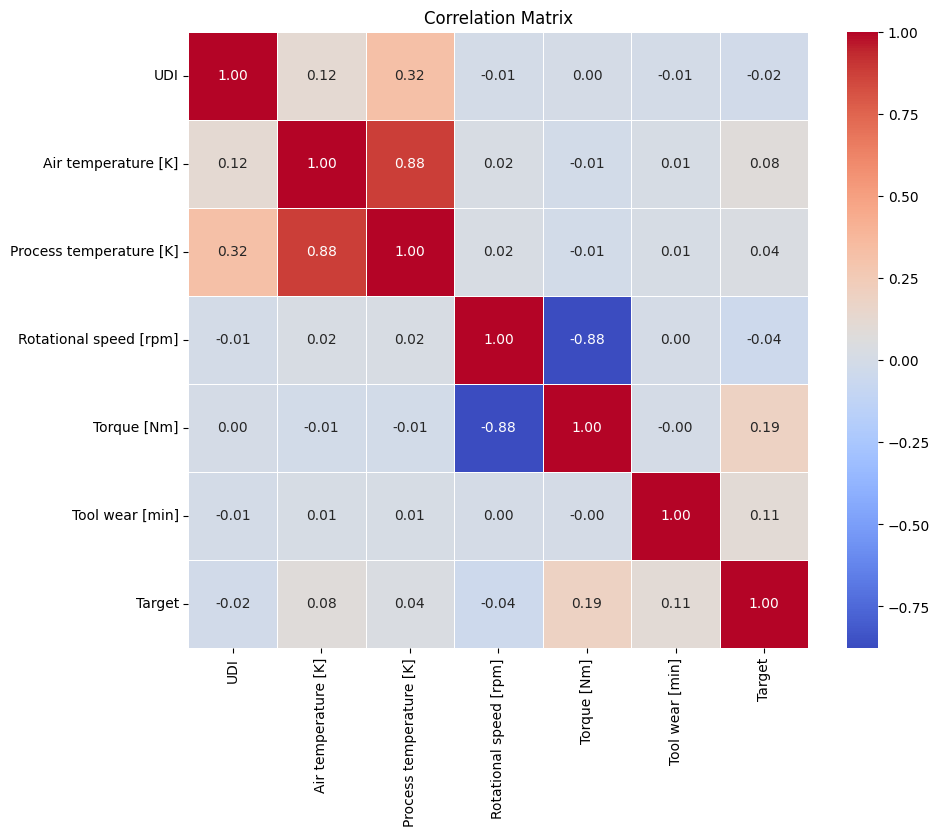

In [7]:
numeric_data = pm_data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates that the highest corelation with the target variablr is only 0.19, suggesting that there is a non linear relationship. There is a high correlation between temperatures, which is in line with the understanding of the process. Considering that the evolution of the difference between the two could be the cause of the heat dissipation failure, we might keep both.

## 3. Remove Non‑Predictive Identifiers
UDI and Product ID are identifiers and do not carry predictive information.

In [18]:
# Maybe do some feature engineering here to add some graphs
pm_data_cleaned = pm_data.drop(['UDI','Product ID'], axis = 1)
pm_data_cleaned.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.10,308.60,1551,42.80,0,0,No Failure
1,L,298.20,308.70,1408,46.30,3,0,No Failure
2,L,298.10,308.50,1498,49.40,5,0,No Failure
3,L,298.20,308.60,1433,39.50,7,0,No Failure
4,L,298.20,308.70,1408,40.00,9,0,No Failure


## 4. Visualisations

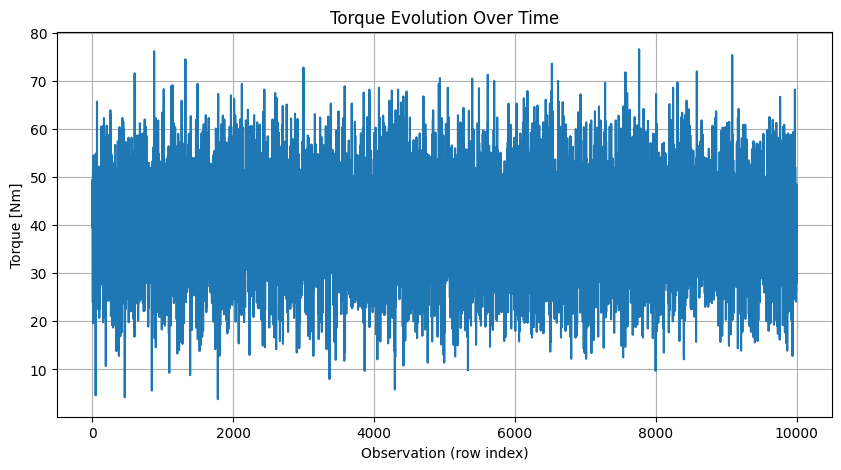

In [19]:
plt.figure(figsize=(10,5))
plt.plot(pm_data['Torque [Nm]'])  # adjust column name if needed

plt.title("Torque Evolution Over Time")
plt.xlabel("Observation (row index)")
plt.ylabel("Torque [Nm]")

plt.grid(True)
plt.show()

Torque fluctuates over time but does not show a clear global trend. Local spikes may correspond to abnormal machine behaviour preceding failures.


<Axes: xlabel='Torque [Nm]', ylabel='Rotational speed [rpm]'>

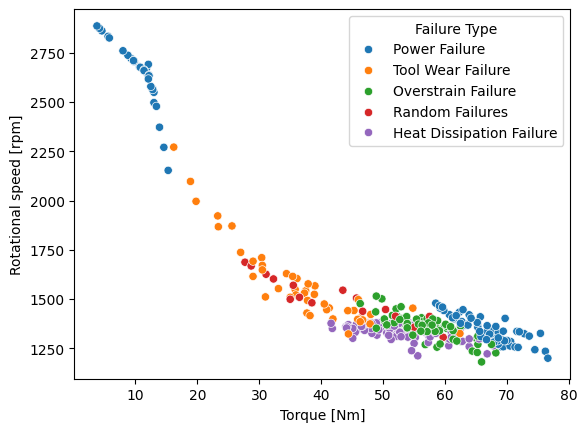

In [29]:
filtered_data = pm_data_cleaned[pm_data_cleaned['Failure Type'] != 'No Failure']

sns.scatterplot(
    data=filtered_data,
    x='Torque [Nm]',
    y='Rotational speed [rpm]',
    hue='Failure Type'
)

The relationship between torque and rotational speed shows overlapping regions between failure and non‑failure observations with an non-linear inverse correlation.
This suggests that **single variables alone may not fully explain failures**, motivating the use of nonlinear models such as Random Forest or Gradient Boosting.


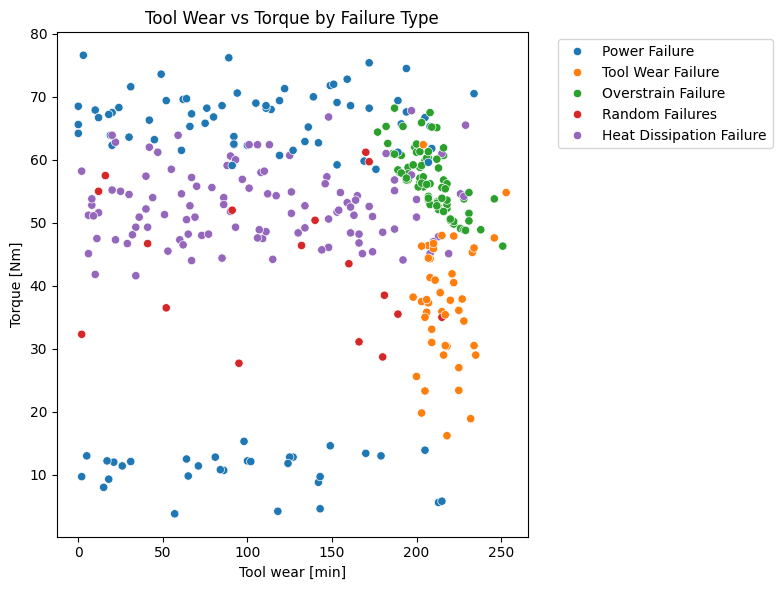

In [ ]:


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=filtered_data,
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='Failure Type'
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Tool Wear vs Torque by Failure Type")

plt.tight_layout()
plt.show()

The plot shows that different failure types cluster in specific regions of tool wear and torque. Tool wear failures occur at very high tool wear levels, while overstrain failures appear at high torque and high wear. The power failure seems to be correlated to both extremes of the torque. Heat dissipation failures occur across a wider range of tool wear,while the torque is relatively constant, and random failures show no clear pattern.

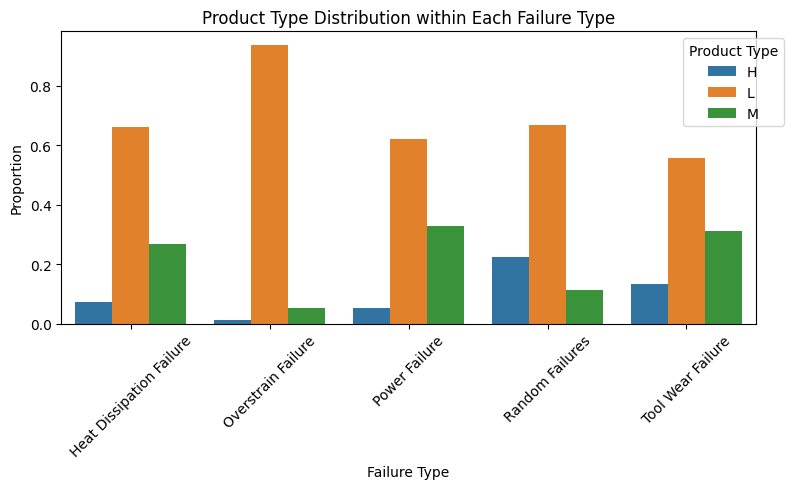

In [30]:

ct = pd.crosstab(
    filtered_data['Failure Type'],
    filtered_data['Type']
)

ct_norm = ct.div(ct.sum(axis=1), axis=0)

ct_long = ct_norm.reset_index().melt(
    id_vars='Failure Type',
    var_name='Product Type',
    value_name='Proportion'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=ct_long,
    x='Failure Type',
    y='Proportion',
    hue='Product Type'
)

plt.title("Product Type Distribution within Each Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Proportion")
plt.xticks(rotation=45)

plt.legend(title="Product Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

The results indicate that product type L dominates across almost all failure types, particularly in overstrain failures, where it accounts for the vast majority of cases. Product type M appears moderately across several failures, especially in power and tool wear failures, while product type H is generally the least frequent.

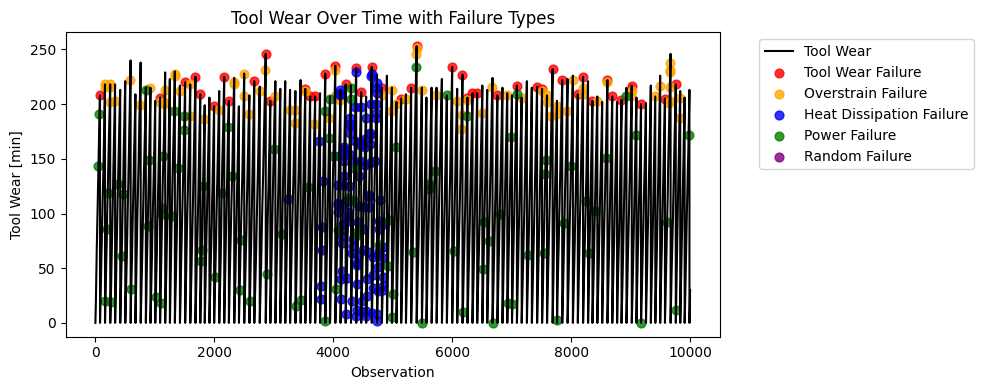

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(pm_data_cleaned['Tool wear [min]'], color='black', label='Tool Wear')

colors = {
    'Tool Wear Failure': 'red',
    'Overstrain Failure': 'orange',
    'Heat Dissipation Failure': 'blue',
    'Power Failure': 'green',
    'Random Failure': 'purple'
}

for ft, color in colors.items():
    subset = pm_data_cleaned[pm_data_cleaned['Failure Type'] == ft]
    
    plt.scatter(
        subset.index,
        subset['Tool wear [min]'],
        color=color,
        label=ft,
        alpha=0.8,
        s=40
    )

plt.title("Tool Wear Over Time with Failure Types")
plt.xlabel("Observation")
plt.ylabel("Tool Wear [min]")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Most tool wear failures and overstrain failures occur at very high tool wear values (around 200–250 minutes), suggesting that failures are more likely when the tool is close to the end of its usable life. In contrast, power failures and heat dissipation failures appear across a wider range of tool wear levels

***SOME tryouts***


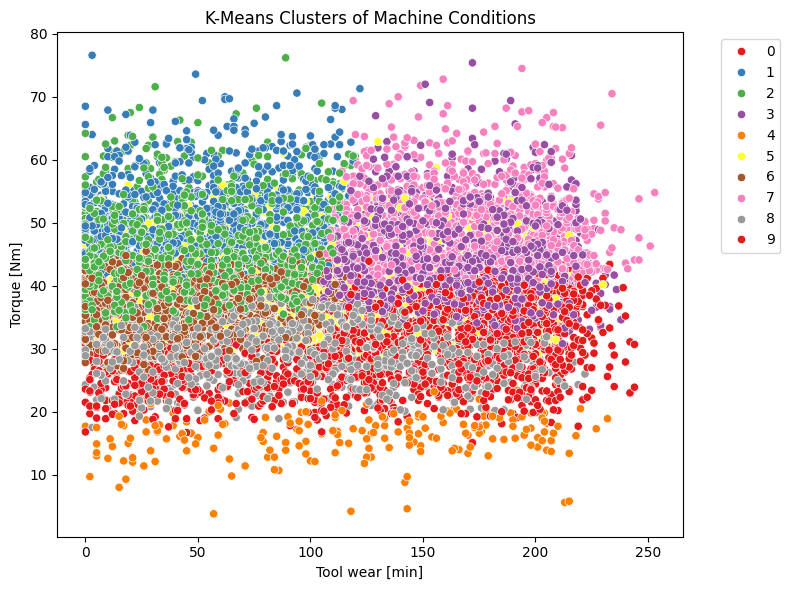

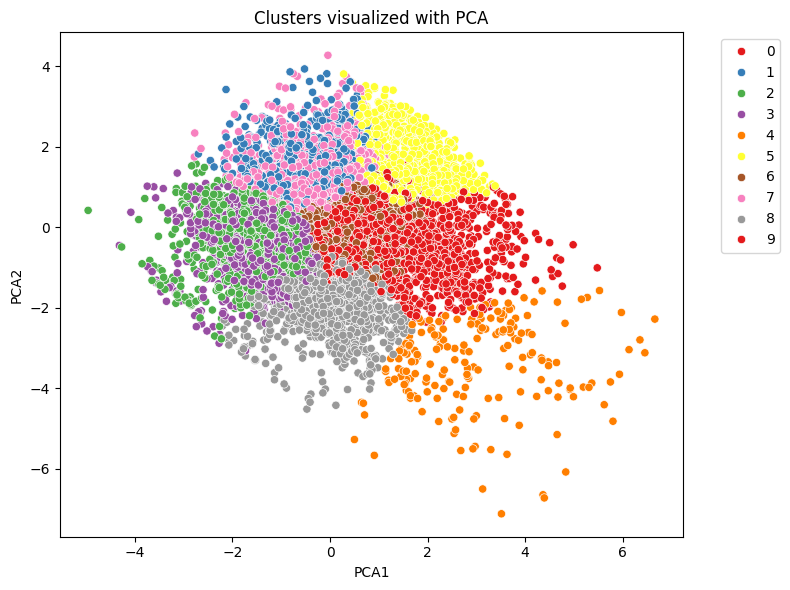

Failure Type  Heat Dissipation Failure  No Failure  Overstrain Failure  \
Cluster                                                                  
0                                    0         593                   0   
1                                   61         897                   0   
2                                    0        1330                   0   
3                                    0        1350                  26   
4                                    0         163                   0   
5                                    5         737                   0   
6                                    0        1295                   0   
7                                   46         998                  52   
8                                    0        1117                   0   
9                                    0        1172                   0   

Failure Type  Power Failure  Random Failures  Tool Wear Failure  
Cluster                                      

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------------
# 1. Select numerical features
# -----------------------------
features = pm_data_cleaned[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]]

# -----------------------------
# 2. Scale the features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -----------------------------
# 3. Run K-Means clustering
# -----------------------------
kmeans = KMeans(n_clusters=10, random_state=42)
pm_data_cleaned['Cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------
# 4. Visualize clusters (Tool wear vs Torque)
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pm_data_cleaned,
    x='Tool wear [min]',
    y='Torque [Nm]',
    hue='Cluster',
    palette='Set1'
)

plt.title("K-Means Clusters of Machine Conditions")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -----------------------------
# 5. PCA visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pm_data_cleaned['PCA1'] = X_pca[:,0]
pm_data_cleaned['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pm_data_cleaned,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Clusters visualized with PCA")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Compare clusters with failures
# -----------------------------
print(pd.crosstab(pm_data_cleaned['Cluster'], pm_data_cleaned['Failure Type']))

In [32]:
import plotly.express as px

fig = px.scatter_3d(
    pm_data_cleaned,
    x='Tool wear [min]',
    y='Torque [Nm]',
    z='Rotational speed [rpm]',
    color='Failure Type',
    opacity=0.6
)

fig.update_layout(title="3D Interaction of Features")
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [ ]:



# Flag reset
pm_data_cleaned['tool_reset'] = (
    pm_data_cleaned['Tool wear [min]'].diff() < -100
)
# create cycle id
pm_data_cleaned['cycle_id'] = pm_data_cleaned['tool_reset'].cumsum()

# normalise with each cycle
pm_data_cleaned['tool_wear_normalized'] = (
    pm_data_cleaned.groupby('cycle_id')['Tool wear [min]'].transform(lambda x: x / x.max()))


pm_data_cleaned['is_near_failure'] = (
    pm_data_cleaned['Tool wear [min]'] > 180
).astype(int)

pm_data_cleaned.head()
    

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,tool_reset,cycle_id,tool_wear_normalized,is_near_failure
0,M,298.10,308.60,1551,42.80,0,0,No Failure,False,0,0.00,0
1,L,298.20,308.70,1408,46.30,3,0,No Failure,False,0,0.01,0
2,L,298.10,308.50,1498,49.40,5,0,No Failure,False,0,0.02,0
3,L,298.20,308.60,1433,39.50,7,0,No Failure,False,0,0.03,0
4,L,298.20,308.70,1408,40.00,9,0,No Failure,False,0,0.04,0
